In [7]:
!pip install pandas scikit-learn matplotlib

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/CarPrice.csv.csv")

# Show first 5 rows
print(df.head())

# Show column names
print(df.columns)

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [9]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          2   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.85        6900          2   
3  wagon r  2011           2.85           4.15        5200          2   
4    swift  2014           4.60           6.87       42450          1   

   Seller_Type  Transmission  Owner  
0            0             1      0  
1            0             1      0  
2            0             1      0  
3            0             1      0  
4            0             1      0  


In [11]:
df = df.drop('Car_Name', axis=1)

print(df.head())
print(df.columns)

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          2   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.85        6900          2   
3  wagon r  2011           2.85           4.15        5200          2   
4    swift  2014           4.60           6.87       42450          1   

   Seller_Type  Transmission  Owner  
0            0             1      0  
1            0             1      0  
2            0             1      0  
3            0             1      0  
4            0             1      0  


In [16]:
y = df['Selling_Price']

In [17]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(X.head())
print(y.head())

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [27]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print("X and y created successfully!")

X and y created successfully!


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (240, 8)
Testing data shape: (61, 8)


In [31]:
print(X.columns)

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [32]:
print("df columns before dropping:", df.columns)
X = df.drop(['Selling_Price', 'Car_Name'], axis=1)
y = df['Selling_Price']

print(X.head())
print("X columns after dropping:", X.columns)

  Car_Name  Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0     ritz  2014           5.59       27000          2            0   
1      sx4  2013           9.54       43000          1            0   
2     ciaz  2017           9.85        6900          2            0   
3  wagon r  2011           4.15        5200          2            0   
4    swift  2014           6.87       42450          1            0   

   Transmission  Owner  
0             1      0  
1             1      0  
2             1      0  
3             1      0  
4             1      0  


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split successfully!")

Data split successfully!


In [35]:
print(X.columns)

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [36]:
# Remove Car_Name and Selling_Price
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)

# Target variable
y = df['Selling_Price']

print(X.columns)

Index(['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner'],
      dtype='object')


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [40]:
predictions = model.predict(X_test)

print("First 5 predicted car prices:")
print(predictions[:5])

First 5 predicted car prices:
[ 2.96670467  8.3025584   6.05620758 -1.46814968  9.25713882]


In [41]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R² Score:", score)

R² Score: 0.8468053957655803


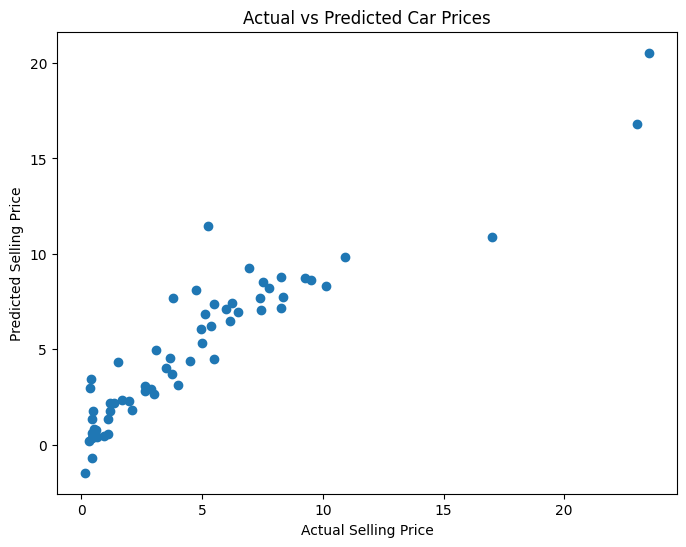

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()